In [4]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [5]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [6]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ Vinc)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

def evalObj(Ivec):
    return(-np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0)

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObj(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


In [7]:

Pdiags = np.ones((Ndes,1), dtype=complex)
Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

Bmat = Obj
bVec = obj
beta = obj0

Xi = np.linalg.inv(1j*Zmat)
G0 = -1j*Z0

Prec = np.linalg.inv(G0)

Umat = Prec @ (np.eye(Ndes) - Xi @ G0)
eVec = Prec @ Xi @ (1j * Vinc)

B_j = [-Ztot]
s_2j = [-Vinc/2]
c_2j = [0]

QCQP = DenseSharedProjQCQP(
    Bmat, bVec, beta,
    Umat.conj().T, eVec,
    Plist,
    A2=np.eye(Ndes, dtype=complex),
    B_j=B_j,
    s_2j=s_2j,
    c_2j=c_2j,
    verbose=1,
)

t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1]+1,))
lags_init[1] = -1

# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-4,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 0.0001
gradConverge: True
min_inner_iter: 10
max_restart: 10
penalty_ratio: 0.01
penalty_reduction: 0.1
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [ 0. -1.]
Outer iteration 0, penalty_ratio = 0.01, opt_fx = 12.229409615220948
iter_num: 5, prev_fx: inf, opt_fx: 11.404167283564698, opttol: 0.0001
iter_num: 10, prev_fx: 11.404167283564698, opt_fx: 11.3825264099067, opttol: 0.0001
Outer iteration 1, penalty_ratio = 0.001, opt_fx = 11.382523859079361
iter_num: 5, prev_fx: 11.3825264099067, opt_fx: 11.382523859079107, opttol: 0.0001
bound: 1.1383e+01, time: 0.05553698539733887s, Lagrange multipliers: [ 6.35860358e-04 -9.56662016e-01]


In [8]:
# A is the total system matrix. Here I'm checking the minimum eigenvalue to see how PSD it is.
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimum eigenvalue: {np.min(np.real(eigenvals))}")
 

Pdiags = QCQP.Proj.Pdiags


Ivec = QCQP.current_xstar
Popt = evalObj(Ivec) # optimal objective value
print(f"Optimal objective value: {Popt:.6e} W")

minimum eigenvalue: 0.03713729217418663
Optimal objective value: 1.138253e+01 W


In [9]:
from dolphindes.cvxopt.gcd import GCDHyperparameters
import copy
gcd_QCQP = copy.deepcopy(QCQP)

t = time.time()
opt_params = OptimizationHyperparameters(
    opttol=1e-6,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0              
)

gcd_params = GCDHyperparameters(
    gcd_tol=1e-6,                 # Keep extremely tight to prevent early exit
    max_proj_cstrt_num=50,       # CRITICAL: > 390. Safely covers all complex degrees of freedom!
    max_gcd_iter_num=100,         # Increased to give GCD enough runway to generate up to 400 constraints
    gcd_iter_period=5,            # Check for convergence every 2*Nopt iterations to give GCD enough time to generate constraints and converge
    orthonormalize=True,         # Keep OFF so complex phase information isn't scrambled
    opt_params=opt_params
)
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f'gcd optimization took time {time.time()-t}.')

Precomputed 2 A matrices and Fs vectors.
At GCD iteration #1, best dual bound found is             11.382523859078706.
min eigenvalue: 3.713730e-02
At GCD iteration #2, best dual bound found is             10.764659411295238.
min eigenvalue: 7.695350e-03
At GCD iteration #3, best dual bound found is             10.685635866705894.
min eigenvalue: 6.774712e-04
At GCD iteration #4, best dual bound found is             10.678869905879168.
min eigenvalue: 1.331637e-04
At GCD iteration #5, best dual bound found is             10.676535328415175.
min eigenvalue: 8.228583e-05
At GCD iteration #6, best dual bound found is             10.66573955849294.
min eigenvalue: 2.868332e-04
At GCD iteration #7, best dual bound found is             10.660447401254856.
min eigenvalue: 3.194309e-04
At GCD iteration #8, best dual bound found is             10.65410422896931.
min eigenvalue: 1.597023e-04
At GCD iteration #9, best dual bound found is             10.653305132105595.
min eigenvalue: 1.277998e-0

In [10]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 0.0005128268973199484


In [11]:
# Now I take the solved gcd_QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = gcd_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcd_QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = gcd_QCQP.current_lags
Pdiags = gcd_QCQP.Proj.Pdiags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

Ivec= gcd_QCQP.current_xstar

primar_obj = evalObj(Ivec)
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {gcd_QCQP.current_dual}")

bound: 10.627749573553517, time: 0.33455491065979004s
min eigenvalue: 0.0006358987555604451
GCD primary objective: 10.612938100065879
GCD dual bound: 10.627749573553517


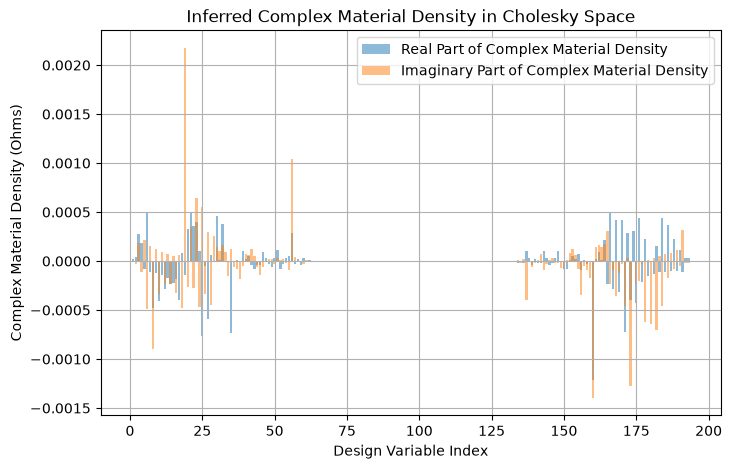

In [12]:
Vopt = Z0 @ Ivec
Vinf = Vinc - Vopt

sigmaInf = Ivec/Vinf
sigmaFull = 1/Zs

complexMaterialDensity = sigmaInf/sigmaFull

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density (Ohms)')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


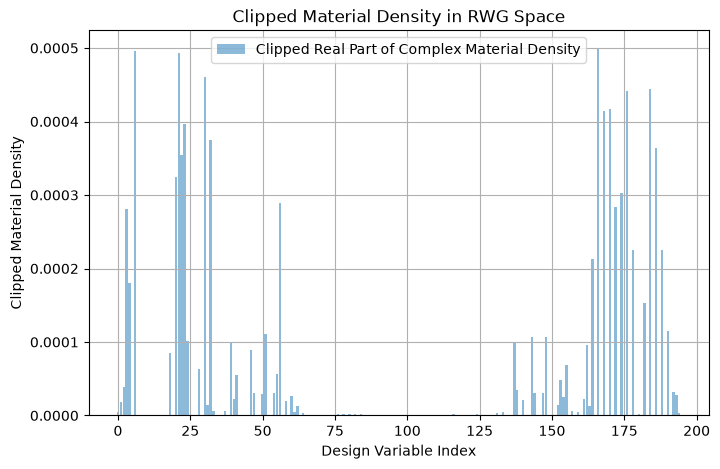

Objective for clipped inferred material density: 1.3346e-07 W


In [13]:
# limit material density to be postive real [0,1]
material_density = np.clip(np.real(complexMaterialDensity), 0, 1)
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), material_density, alpha=0.5, label='Clipped Real Part of Complex Material Density')
plt.xlabel('Design Variable Index') 
plt.ylabel('Clipped Material Density')
plt.title('Clipped Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

sigmaClipped = 1/Zs*material_density
IfullInfClip = np.linalg.solve(np.eye(Ndes) + np.diag(sigmaClipped) @ Z0, np.diag(sigmaClipped) @ Vinc) # current distribution for inferred material density
PfullInfClip= evalObj(IfullInfClip) # radiated power for inferred material density
print(f"Objective for clipped inferred material density: {PfullInfClip:.4e} W")